In [3]:
!pip install opencv-python-headless
!pip install scikit-learn
!pip install efficientnet

In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import glob

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score,roc_auc_score, f1_score,confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.backend
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, GlobalAveragePooling2D

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_007_132.mp4_frame4.jpg
/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_038_125.mp4_frame4.jpg
/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_008_990.mp4_frame1.jpg
/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_001_870.mp4_frame1.jpg
/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_022_489.mp4_frame4.jpg
/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_040_997.mp4_frame4.jpg
/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_035_036.mp4_frame3.jpg
/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_027_009.mp4_frame3.jpg
/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_012_026.mp4_frame1.jpg
/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_017_803.mp4_frame1.jpg
/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_028_068.mp4_frame4.jpg
/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_005_010.mp4_frame3.jpg
/kaggle/input/faceforensics-

In [7]:
# paths
faceforensis_real_path = "/kaggle/input/faceforensics-face/REAL"
faceforensis_fake_deepfake = "/kaggle/input/faceforensics-face/Deepfake"
faceforensis_fake_deepfakedetection = "/kaggle/input/faceforensics-face/DeepfakeDetection"
faceforensis_fake_face2face = "/kaggle/input/faceforensics-face/Face2Face"
faceforensis_fake_faceshifter = "/kaggle/input/faceforensics-face/FaceShifter"
faceforensis_fake_faceswap = "/kaggle/input/faceforensics-face/FaceSwap"
faceforensis_fake_neuraltextures = "/kaggle/input/faceforensics-face/NeuralTextures"

# models
vgg_model = VGG16(weights='imagenet', include_top=False, pooling='avg')
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
eff_model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')

2025-05-05 13:14:03.078394: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["REAL", "FAKE"])
    plt.figure(figsize=(5, 5))
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

In [9]:
def extract_features_from_image(image_path): 
    # Verifica se o arquivo é uma imagem válida
    if not os.path.isfile(image_path):
        print(f"[ERRO] O arquivo {image_path} não é válido ou não é uma imagem.")
        return None

    # Carrega a imagem
    img = cv2.imread(image_path)
    if img is None:
        print(f"[ERRO] Não foi possível carregar a imagem {image_path}.")
        return None

    # Redimensiona a imagem
    img_resized = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # Processamento para VGG, ResNet e EfficientNet
    img_batch_vgg = preprocess_vgg(np.expand_dims(img_rgb.astype('float32'), axis=0))
    img_batch_resnet = preprocess_resnet(np.expand_dims(img_rgb.astype('float32'), axis=0))
    img_batch_eff = preprocess_eff(np.expand_dims(img_rgb.astype('float32'), axis=0))

    vgg_feat = vgg_model.predict(img_batch_vgg, verbose=0).flatten()
    res_feat = resnet_model.predict(img_batch_resnet, verbose=0).flatten()
    eff_feat = eff_model.predict(img_batch_eff, verbose=0).flatten()

    combined = np.concatenate([vgg_feat, res_feat, eff_feat])

    return combined  # Retorne a combinação das features

def generate_model(real_path, fake_path):
    X_train, y_train = [], []
    X_test, y_test = [], []

    for label, path in [("REAL", real_path), ("FAKE", fake_path)]:
        image_files = os.listdir(path)
        test_files = image_files[:50]
        train_files = image_files[50:]

        for image_name in tqdm(test_files, desc=f"{label} (TESTE)"):
            image_path = os.path.join(path, image_name)
            feat = extract_features_from_image(image_path)
            if feat is not None:
                X_test.append(feat)
                y_test.append(0 if label == "REAL" else 1)
            else:
                print(f"[INFO] Não foram extraídas características de {image_path}")

        for image_name in tqdm(train_files, desc=f"{label} (TREINO)"):
            image_path = os.path.join(path, image_name)
            feat = extract_features_from_image(image_path)
            if feat is not None:
                X_train.append(feat)
                y_train.append(0 if label == "REAL" else 1)
            else:
                print(f"[INFO] Não foram extraídas características de {image_path}")

    if len(X_train) == 0 or len(X_test) == 0:
        print("Erro: Não foram extraídas características suficientes para o treino ou teste.")
        return None, None

    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    # PCA + SVM
    pca = PCA(n_components=10)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    svm = SVC(kernel='linear')
    svm.fit(X_train_pca, y_train)

    y_pred = svm.predict(X_test_pca)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))

    if hasattr(svm, "decision_function"):
        y_scores = svm.decision_function(X_test_pca)
        auc = roc_auc_score(y_test, y_scores)
        print("AUC:", auc)
    else:
        print("O modelo SVM não possui decision_function para calcular a AUC.")

    print("Classification Report:\n", classification_report(y_test, y_pred))

    return svm, pca

In [10]:
# Chamada da função
print("Deepfake")
svm_deepfake, pca_deepfake = generate_model(faceforensis_real_path, faceforensis_fake_deepfake)
print("DeepfakeDetection")
svm_deepfakedetection, pca_deepfakedetection = generate_model(faceforensis_real_path, faceforensis_fake_deepfakedetection)
print("Face2Face")
svm_face2face, pca_face2face = generate_model(faceforensis_real_path, faceforensis_fake_face2face)
print("FaceShifter")
svm_faceshifter, pca_faceshifter = generate_model(faceforensis_real_path, faceforensis_fake_faceshifter)
print("FaceSwap")
svm_faceswap, pca_faceswap = generate_model(faceforensis_real_path, faceforensis_fake_faceswap)
print("NeuralTextures")
svm_neuratextures, pca_neuratextures = generate_model(faceforensis_real_path, faceforensis_fake_neuraltextures)

Deepfake


FAKE (TREINO): 100%|██████████| 200/200 [02:19<00:00,  1.44it/s]


Accuracy: 0.71
F1-score (macro): 0.7092731829573935
AUC: 0.7295999999999999
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.76      0.72        50
           1       0.73      0.66      0.69        50

    accuracy                           0.71       100
   macro avg       0.71      0.71      0.71       100
weighted avg       0.71      0.71      0.71       100

DeepfakeDetection


FAKE (TREINO): 100%|██████████| 200/200 [02:21<00:00,  1.41it/s]


Accuracy: 0.97
F1-score (macro): 0.96999699969997
AUC: 0.9968
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97        50
           1       0.98      0.96      0.97        50

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100

Face2Face


...

Accuracy: 0.56
F1-score (macro): 0.5555555555555556
AUC: 0.6224000000000001
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.46      0.51        50
           1       0.55      0.66      0.60        50

    accuracy                           0.56       100
   macro avg       0.56      0.56      0.56       100
weighted avg       0.56      0.56      0.56       100

FaceSwap


FAKE (TREINO): 100%|██████████| 200/200 [02:25<00:00,  1.37it/s]


Accuracy: 0.58
F1-score (macro): 0.5784825371336814
AUC: 0.6152000000000001
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.64      0.60        50
           1       0.59      0.52      0.55        50

    accuracy                           0.58       100
   macro avg       0.58      0.58      0.58       100
weighted avg       0.58      0.58      0.58       100

NeuralTextures


FAKE (TREINO): 100%|██████████| 200/200 [02:23<00:00,  1.39it/s]


Accuracy: 0.48
F1-score (macro): 0.47916666666666663
AUC: 0.484
Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.44      0.46        50
           1       0.48      0.52      0.50        50

    accuracy                           0.48       100
   macro avg       0.48      0.48      0.48       100
weighted avg       0.48      0.48      0.48       100



In [11]:
def generate_gradcam(model, preprocess_input, layer_name, img):
    img_tensor = preprocess_input(np.expand_dims(img.astype('float32'), axis=0))
    grad_model = Model(
        [model.inputs], 
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = tf.reduce_mean(predictions)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = np.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()
    heatmap = cv2.resize(heatmap, (224, 224))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(cv2.cvtColor(img, cv2.COLOR_RGB2BGR), 0.6, heatmap, 0.4, 0)
    return overlay

In [19]:
def analyze_and_visualize(image_paths, model_name, pca, svm):
    vgg_feats, resnet_feats, eff_feats = [], [], []
    print(f"\n📊 Modelo base para visualização: {model_name}")
    plt.figure(figsize=(20, 5))

    for idx, image_path in enumerate(image_paths):
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Erro ao carregar imagem: {image_path}")
        
        img_resized = cv2.resize(img, (224, 224))
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

        # Preprocessing
        img_vgg = preprocess_vgg(np.expand_dims(img_rgb.astype('float32'), axis=0))
        img_res = preprocess_resnet(np.expand_dims(img_rgb.astype('float32'), axis=0))
        img_eff = preprocess_eff(np.expand_dims(img_rgb.astype('float32'), axis=0))

        # Feature extraction
        vgg_feat = vgg_model.predict(img_vgg, verbose=0).flatten()
        res_feat = resnet_model.predict(img_res, verbose=0).flatten()
        eff_feat = eff_model.predict(img_eff, verbose=0).flatten()

        vgg_feats.append(vgg_feat)
        resnet_feats.append(res_feat)
        eff_feats.append(eff_feat)

        # Grad-CAM (individual)
        if model_name == "VGG16":
            gradcam_result = generate_gradcam(vgg_model, preprocess_vgg, "block5_conv3", img_rgb)
        elif model_name == "ResNet50":
            gradcam_result = generate_gradcam(resnet_model, preprocess_resnet, "conv5_block3_out", img_rgb)
        elif model_name == "EfficientNetB0":
            gradcam_result = generate_gradcam(eff_model, preprocess_eff, "top_activation", img_rgb)

        # Plot Grad-CAM
        plt.subplot(1, 5, idx + 1)
        plt.imshow(gradcam_result)
        plt.axis("off")
        plt.title(f"Frame {idx+1}")

    # Média das features de todos os modelos
    vgg_feats = np.mean(vgg_feats, axis=0)
    resnet_feats = np.mean(resnet_feats, axis=0)
    eff_feats = np.mean(eff_feats, axis=0)
    combined_feat = np.concatenate([vgg_feats, resnet_feats, eff_feats]).reshape(1, -1)

    # PCA + SVM
    combined_feat_pca = pca.transform(combined_feat)
    pred = svm.predict(combined_feat_pca)[0]
    label = "REAL" if pred == 0 else "FAKE"
    print(f"🧠 Classificação final do vídeo: {label}")

    plt.suptitle(f"Grad-CAM - {model_name} ({label})", fontsize=16)
    plt.show()


def analyze_video(frames_list, svm, pca):
    analyze_and_visualize(frames_list, "VGG16", pca, svm)
    analyze_and_visualize(frames_list, "ResNet50", pca, svm)
    analyze_and_visualize(frames_list, "EfficientNetB0", pca, svm)


### Deepfake


📊 Modelo base para visualização: VGG16
🧠 Classificação final do vídeo: FAKE


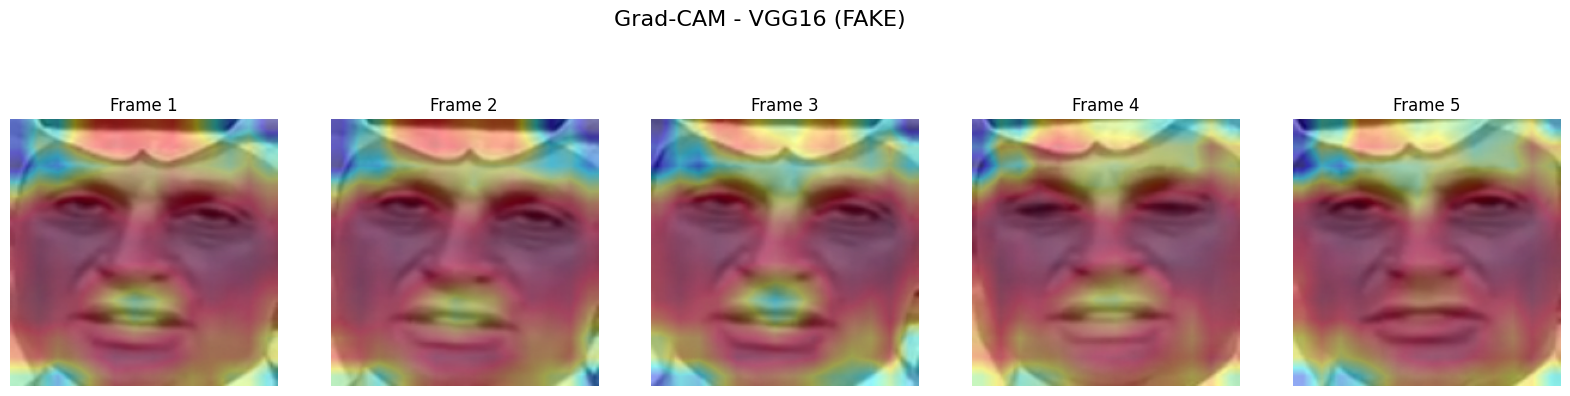


📊 Modelo base para visualização: ResNet50
🧠 Classificação final do vídeo: FAKE


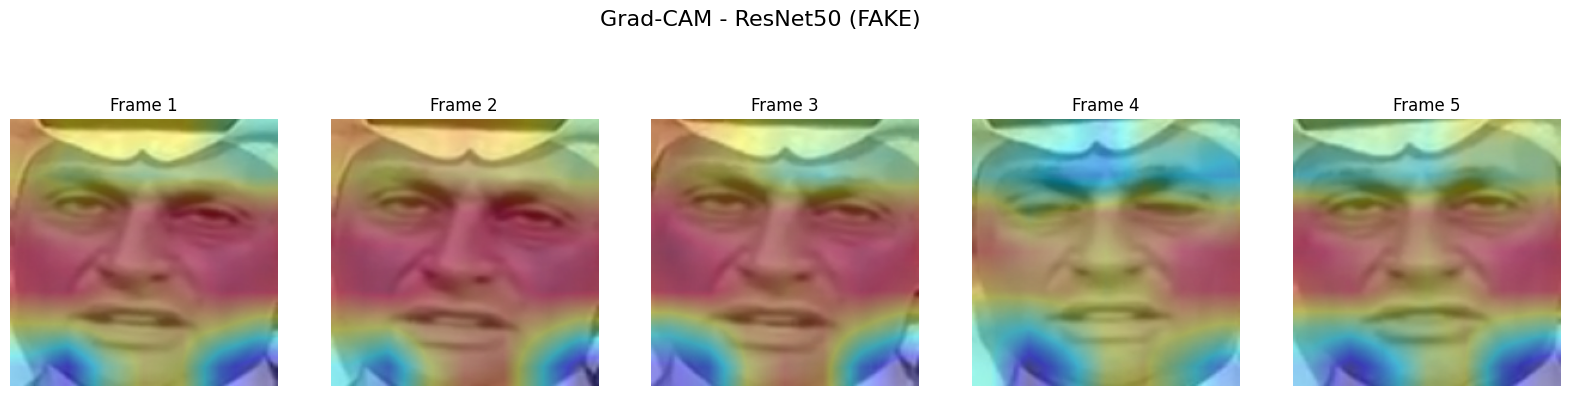


📊 Modelo base para visualização: EfficientNetB0
🧠 Classificação final do vídeo: FAKE


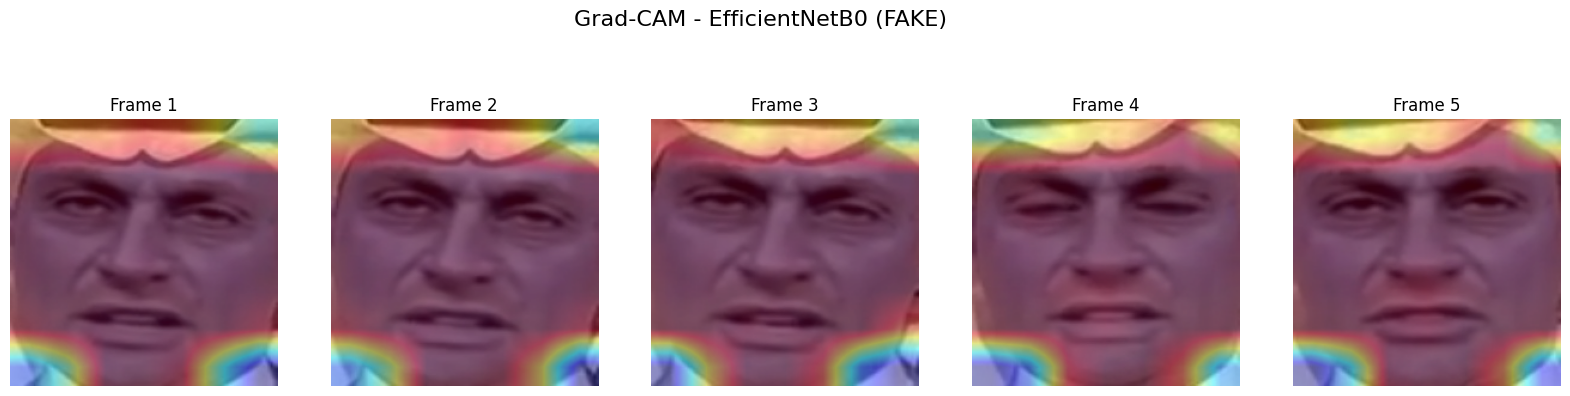

In [20]:
frames = [
    '/kaggle/input/faceforensics-face/Deepfake/FAKE-Deepfake_000_003.mp4_frame1.jpg',
    '/kaggle/input/faceforensics-face/Deepfake/FAKE-Deepfake_000_003.mp4_frame2.jpg',
    '/kaggle/input/faceforensics-face/Deepfake/FAKE-Deepfake_000_003.mp4_frame3.jpg',
    '/kaggle/input/faceforensics-face/Deepfake/FAKE-Deepfake_000_003.mp4_frame4.jpg',
    '/kaggle/input/faceforensics-face/Deepfake/FAKE-Deepfake_000_003.mp4_frame5.jpg'
]

analyze_video(frames, svm_deepfake, pca_deepfake)

### Face2Face


📊 Modelo base para visualização: VGG16
🧠 Classificação final do vídeo: REAL


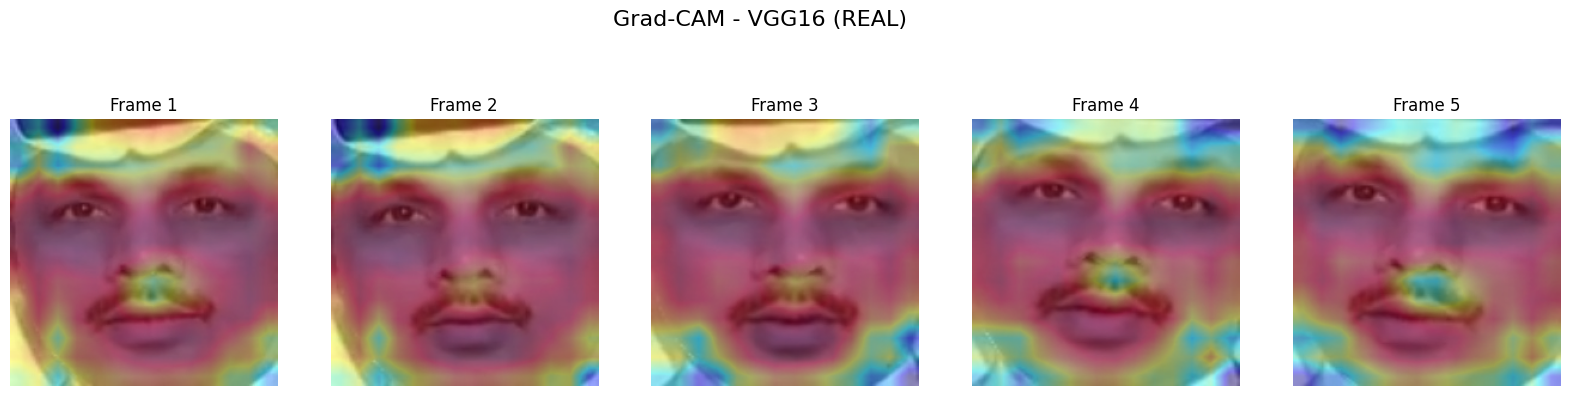


📊 Modelo base para visualização: ResNet50
🧠 Classificação final do vídeo: REAL


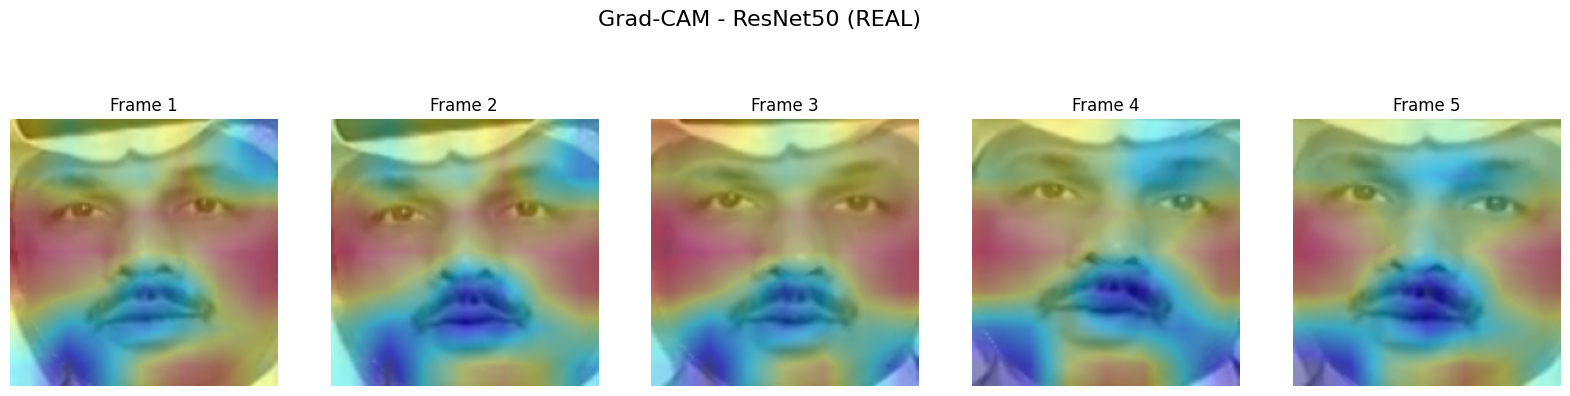


📊 Modelo base para visualização: EfficientNetB0
🧠 Classificação final do vídeo: REAL


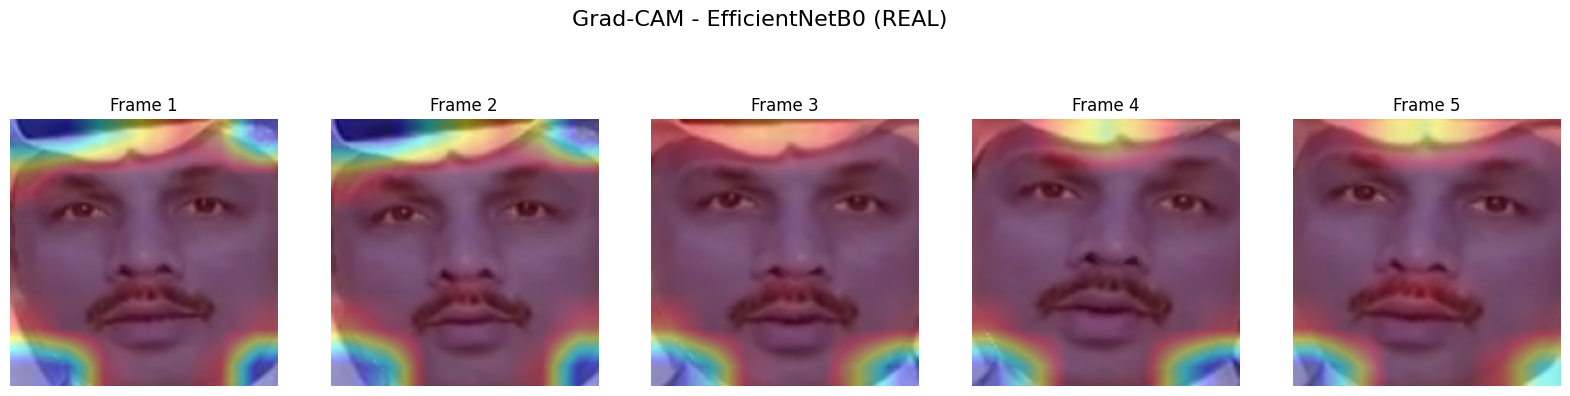

In [21]:
frames = [
    '/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_000_003.mp4_frame1.jpg',
    '/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_000_003.mp4_frame2.jpg',
    '/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_000_003.mp4_frame3.jpg',
    '/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_000_003.mp4_frame4.jpg',
    '/kaggle/input/faceforensics-face/Face2Face/FAKE-Face2face_000_003.mp4_frame5.jpg'
]

analyze_video(frames, svm_face2face, pca_face2face)

### FaceShifter


📊 Modelo base para visualização: VGG16
🧠 Classificação final do vídeo: FAKE


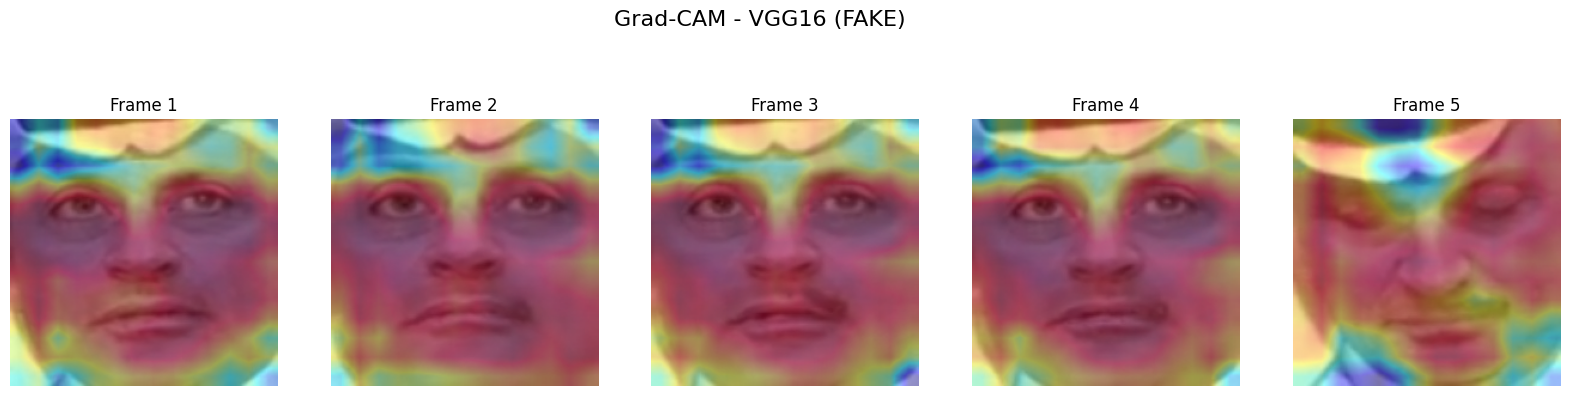


📊 Modelo base para visualização: ResNet50
🧠 Classificação final do vídeo: FAKE


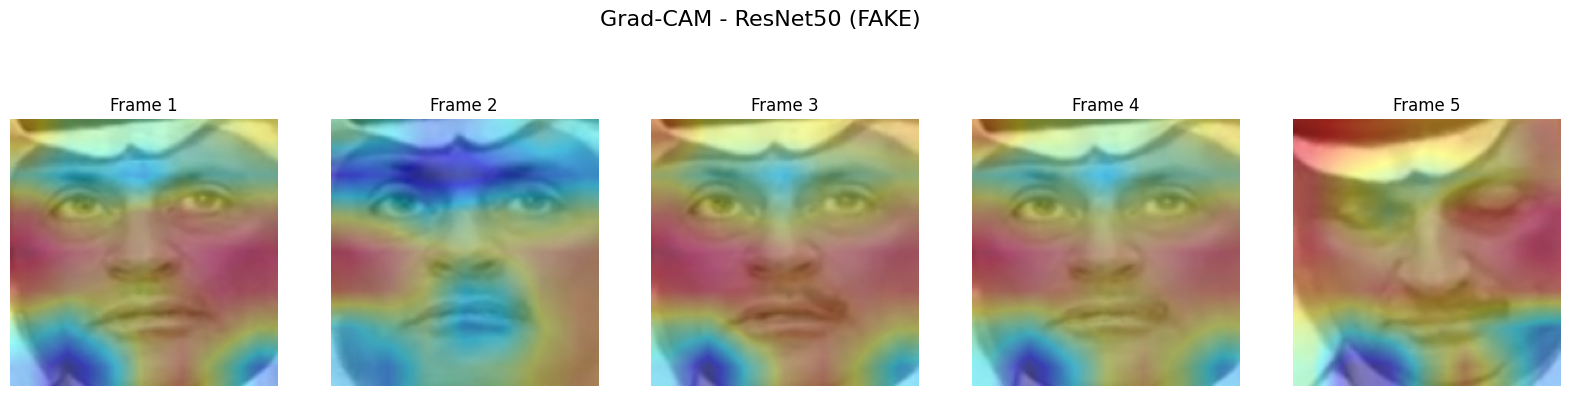


📊 Modelo base para visualização: EfficientNetB0
🧠 Classificação final do vídeo: FAKE


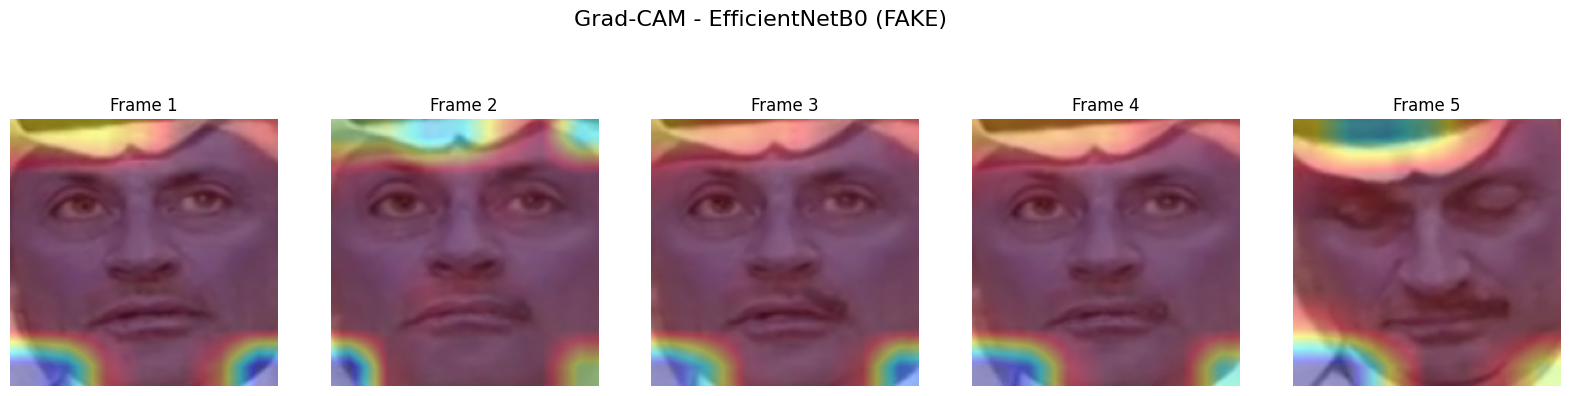

In [22]:
frames = [
    '/kaggle/input/faceforensics-face/FaceShifter/FAKE-faceshifter_000_003.mp4_frame1.jpg',
    '/kaggle/input/faceforensics-face/FaceShifter/FAKE-faceshifter_000_003.mp4_frame2.jpg',
    '/kaggle/input/faceforensics-face/FaceShifter/FAKE-faceshifter_000_003.mp4_frame3.jpg',
    '/kaggle/input/faceforensics-face/FaceShifter/FAKE-faceshifter_000_003.mp4_frame4.jpg',
    '/kaggle/input/faceforensics-face/FaceShifter/FAKE-faceshifter_000_003.mp4_frame5.jpg'
]

analyze_video(frames, svm_faceshifter, pca_faceshifter)

### FaceSwap


📊 Modelo base para visualização: VGG16
🧠 Classificação final do vídeo: FAKE


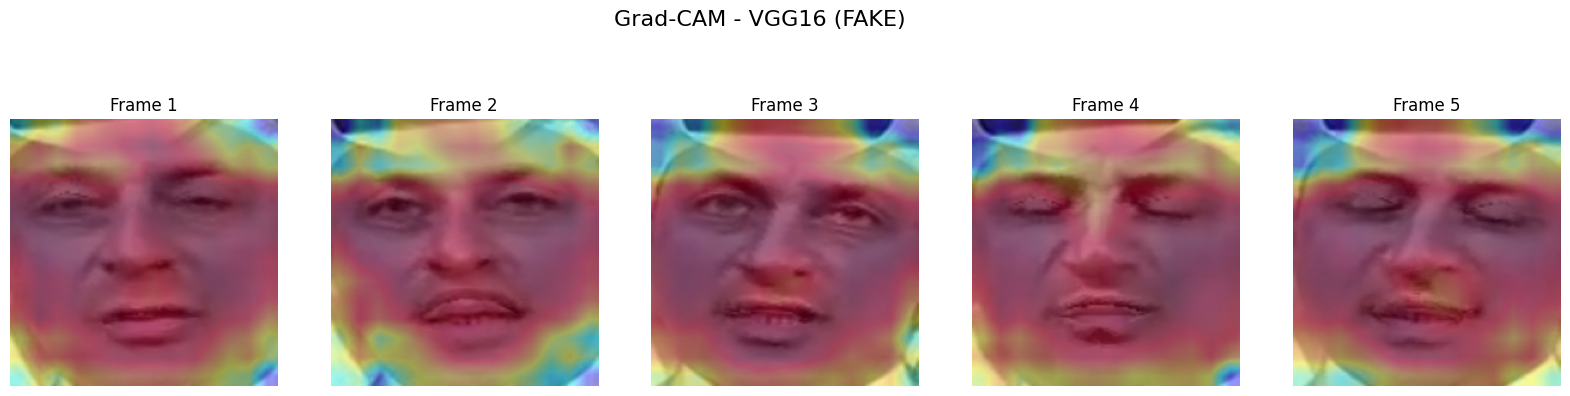


📊 Modelo base para visualização: ResNet50
🧠 Classificação final do vídeo: FAKE


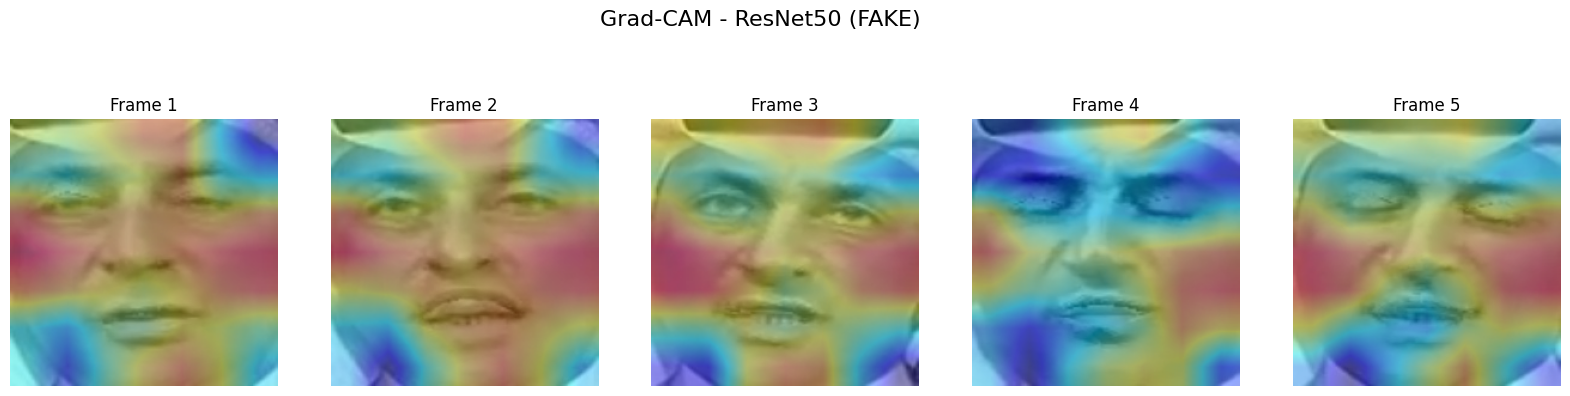


📊 Modelo base para visualização: EfficientNetB0
🧠 Classificação final do vídeo: FAKE


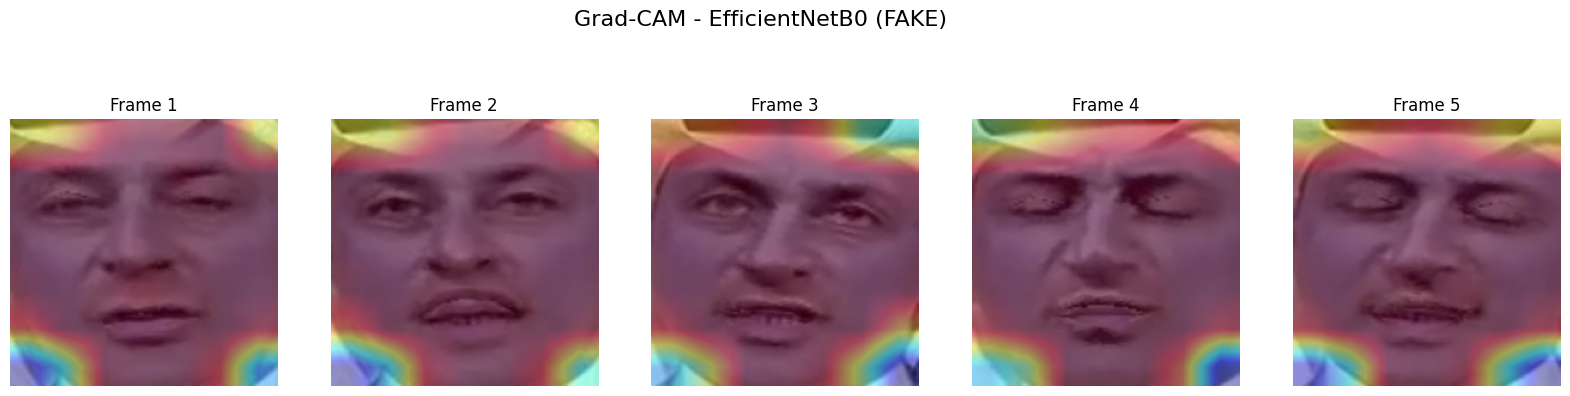

In [23]:
frames = [
    '/kaggle/input/faceforensics-face/FaceSwap/FAKE-faceswap_000_003.mp4_frame1.jpg',
    '/kaggle/input/faceforensics-face/FaceSwap/FAKE-faceswap_000_003.mp4_frame2.jpg',
    '/kaggle/input/faceforensics-face/FaceSwap/FAKE-faceswap_000_003.mp4_frame3.jpg',
    '/kaggle/input/faceforensics-face/FaceSwap/FAKE-faceswap_000_003.mp4_frame4.jpg',
    '/kaggle/input/faceforensics-face/FaceSwap/FAKE-faceswap_000_003.mp4_frame5.jpg'
]

analyze_video(frames, svm_faceswap, pca_faceswap)

### NeuralTextures


📊 Modelo base para visualização: VGG16
🧠 Classificação final do vídeo: REAL


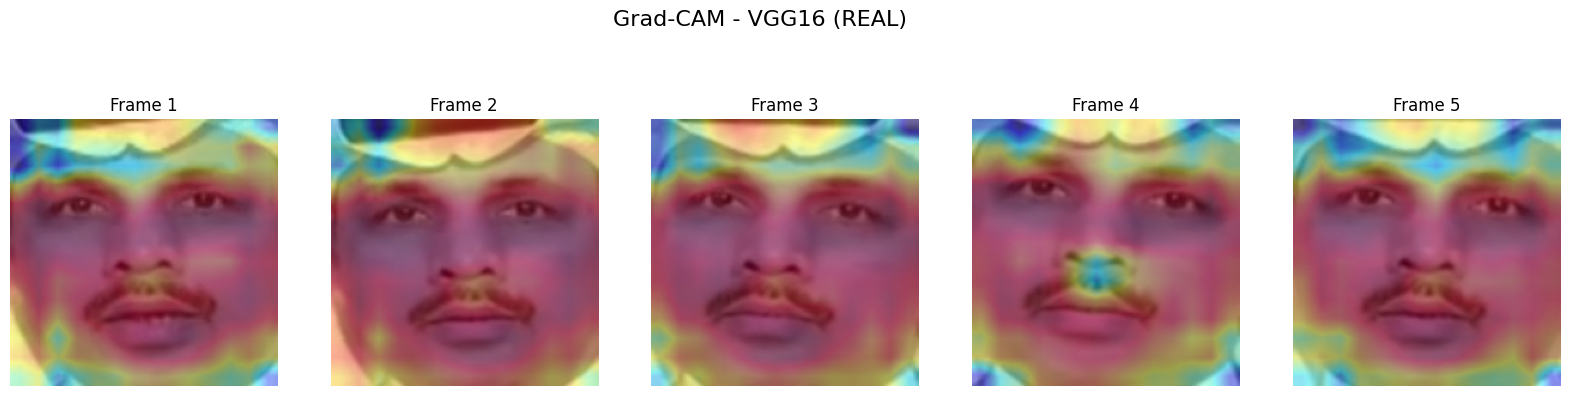


📊 Modelo base para visualização: ResNet50
🧠 Classificação final do vídeo: REAL


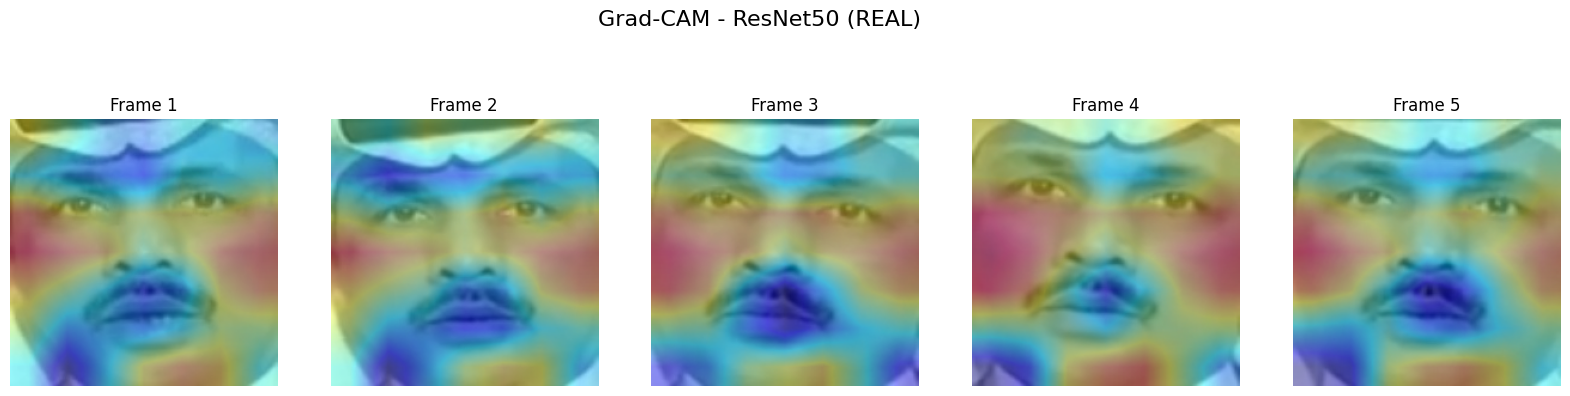


📊 Modelo base para visualização: EfficientNetB0
🧠 Classificação final do vídeo: REAL


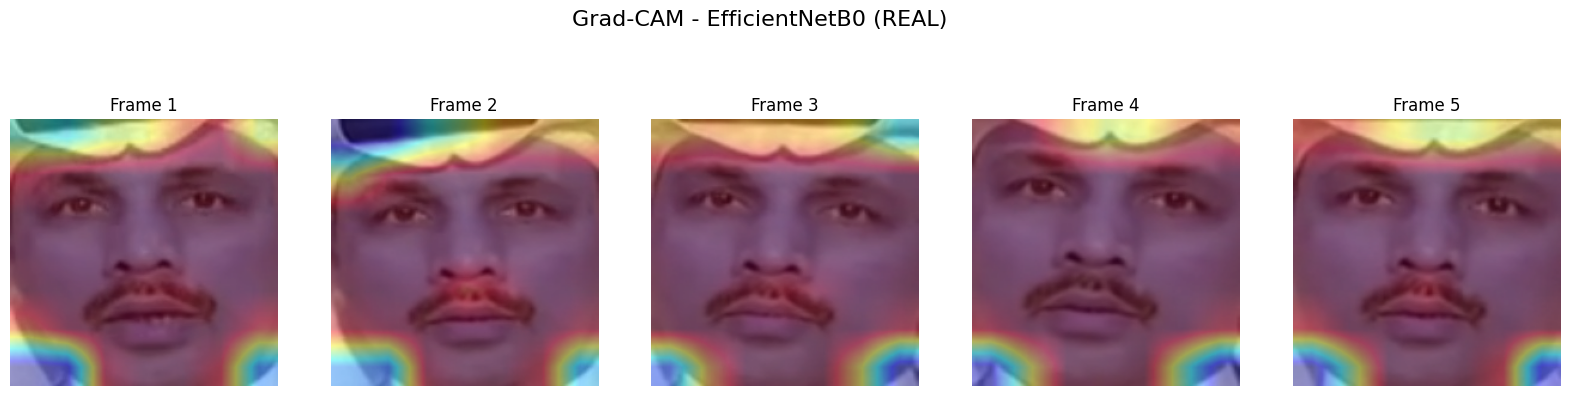

In [24]:
frames = [
    '/kaggle/input/faceforensics-face/NeuralTextures/FAKE-neuraltextures_000_003.mp4_frame1.jpg',
    '/kaggle/input/faceforensics-face/NeuralTextures/FAKE-neuraltextures_000_003.mp4_frame2.jpg',
    '/kaggle/input/faceforensics-face/NeuralTextures/FAKE-neuraltextures_000_003.mp4_frame3.jpg',
    '/kaggle/input/faceforensics-face/NeuralTextures/FAKE-neuraltextures_000_003.mp4_frame4.jpg',
    '/kaggle/input/faceforensics-face/NeuralTextures/FAKE-neuraltextures_000_003.mp4_frame5.jpg'
]

analyze_video(frames, svm_neuratextures, pca_neuratextures)

### Real


📊 Modelo base para visualização: VGG16
🧠 Classificação final do vídeo: REAL


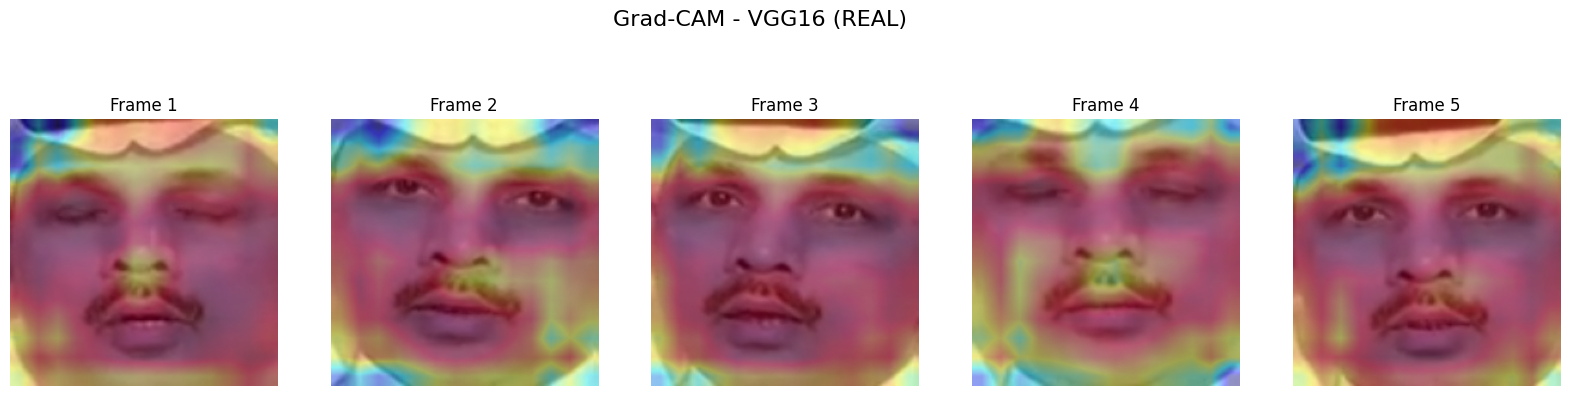


📊 Modelo base para visualização: ResNet50
🧠 Classificação final do vídeo: REAL


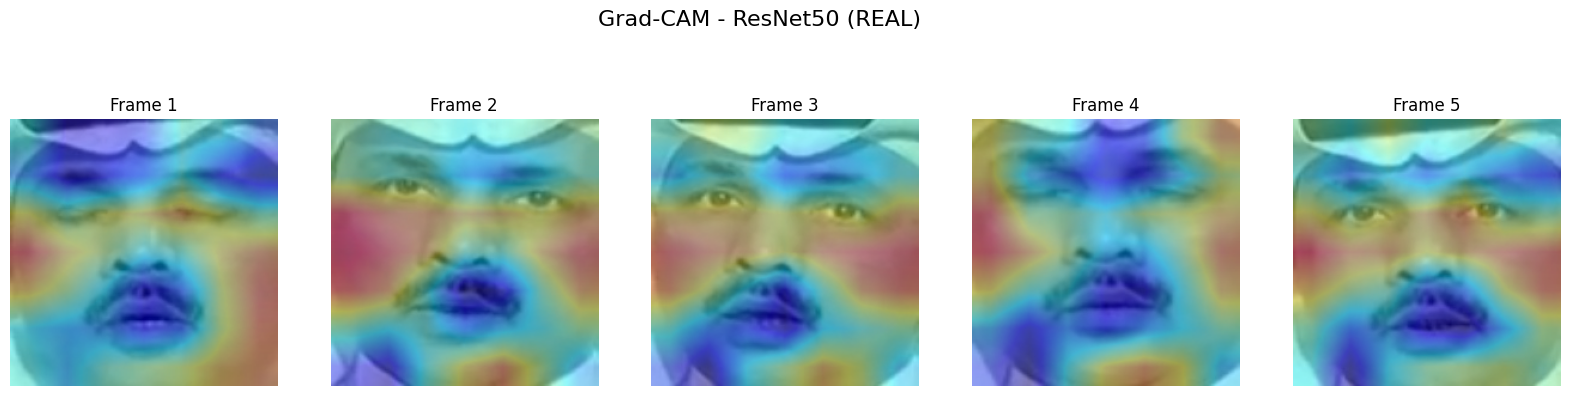


📊 Modelo base para visualização: EfficientNetB0
🧠 Classificação final do vídeo: REAL


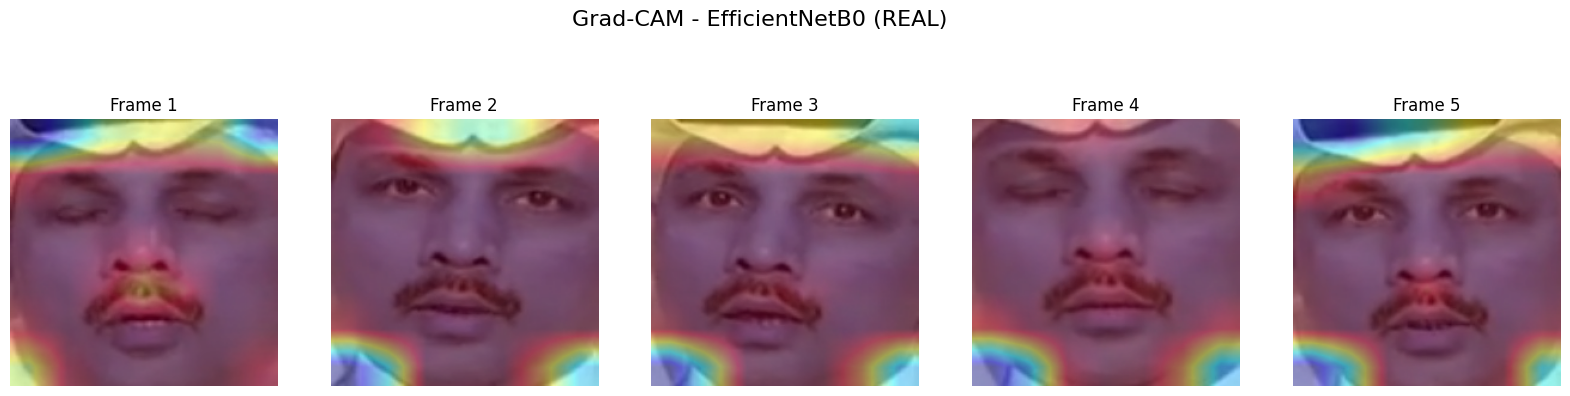

In [26]:
frames = [
    '/kaggle/input/faceforensics-face/REAL/REAL_000.mp4_frame1.jpg',
    '/kaggle/input/faceforensics-face/REAL/REAL_000.mp4_frame2.jpg',
    '/kaggle/input/faceforensics-face/REAL/REAL_000.mp4_frame3.jpg',
    '/kaggle/input/faceforensics-face/REAL/REAL_000.mp4_frame4.jpg',
    '/kaggle/input/faceforensics-face/REAL/REAL_000.mp4_frame5.jpg'
]

analyze_video(frames, svm_deepfakedetection, pca_deepfakedetection)